# INTC vs NVDA — 반도체 해자(moat) 지표 비교 (2011–2025)

**연구 질문:** 인텔과 엔비디아의 경제적 해자는 지난 15년간 어떻게 역전되었는가?

**데이터:** `Moat_Analysis.csv` — WRDS Compustat `comp.fundq`에서 반도체 산업(GICS 453010) 분기 재무를
추출한 것 (추출 파이프라인은 [`Semiconductor_Moat_Analysis.ipynb`](Semiconductor_Moat_Analysis.ipynb) 참고).
**이 노트북은 커밋된 CSV만 사용하므로 WRDS 계정 없이 재현 가능하다.**

**해자 지표 정의:**

| 지표 | 정의 | 해석 |
|---|---|---|
| Gross Margin | (revtq − cogsq) / revtq | 해자가 있으면 원가 상승을 판가에 전가할 수 있어 방어됨 |
| NOPAT-ROA (연환산) | oiadpq × (1 − 유효세율) / atq × 4 | 세후 영업이익 기준 자산수익률 — 자본 효율성 |
| Marketing Efficiency | saleq / xsgaq | 해자가 있는 기업은 판관비를 덜 쓰고도 팔린다 |
| Revenue YoY | revtq의 4분기 전 대비 성장률 | 수요 견인력 |

> 유효세율은 `txtq/piq`를 세전이익이 양수일 때만 취하고 [0, 0.5]로 클리핑, 그 외엔 21% 가정.
> 투하자본(부채+자기자본) 데이터를 추출하지 않았으므로 엄밀한 ROIC 대신 **총자산 기준 NOPAT-ROA**를 사용한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("Moat_Analysis.csv", parse_dates=["datadate"])
print(f"{df.shape[0]:,}행 / 티커 {df['ticker'].nunique()}개 / 기간 {df['datadate'].min():%Y-%m} ~ {df['datadate'].max():%Y-%m}")

7,902행 / 티커 252개 / 기간 2011-01 ~ 2025-12


In [2]:
# 세후 영업 ROA (연환산) — 유효세율은 세전이익 양수일 때만, [0, 0.5] 클리핑, 그 외 21% 가정
eff_tax = (df["txtq"] / df["piq"]).where(df["piq"] > 0).clip(0, 0.5).fillna(0.21)
df["nopat_roa"] = df["oiadpq"] * (1 - eff_tax) / df["atq"].replace(0, np.nan) * 4

pair = df[df["ticker"].isin(["INTC", "NVDA"])].copy()
pair["year"] = pair["datadate"].dt.year
pair.groupby("ticker").agg(quarters=("datadate", "count"),
                           start=("datadate", "min"), end=("datadate", "max"))

,quarters,start,end
ticker,,,
INTC,60,2011-03-31,2025-12-31
NVDA,60,2011-01-31,2025-10-31


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


...

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


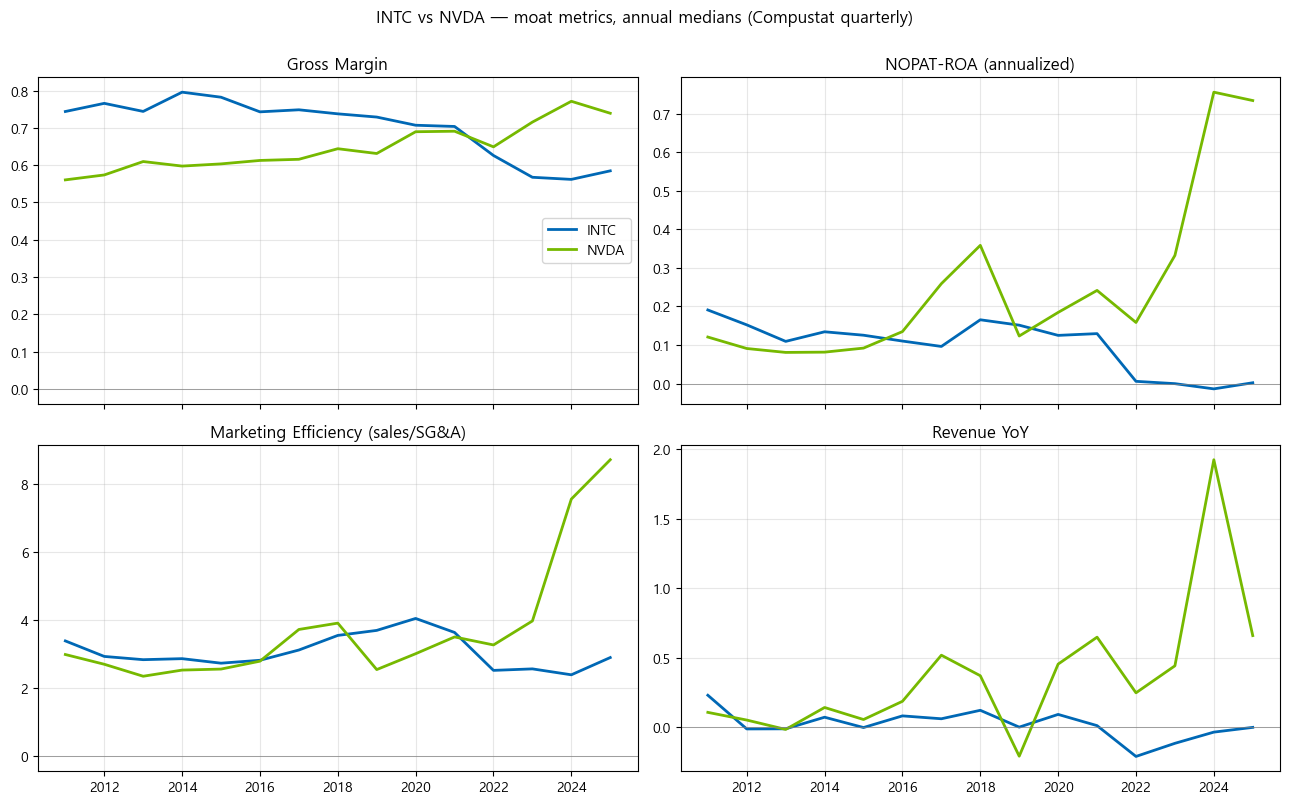

In [3]:
METRICS = {"gross_margin": "Gross Margin",
           "nopat_roa": "NOPAT-ROA (annualized)",
           "marketing_effi": "Marketing Efficiency (sales/SG&A)",
           "rev_growth_yoy": "Revenue YoY"}
annual = (pair.groupby(["ticker", "year"])[list(METRICS)].median().reset_index())

COLORS = {"INTC": "#0068B5", "NVDA": "#76B900"}
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (col, title) in zip(axes.flat, METRICS.items()):
    for t in ["INTC", "NVDA"]:
        s = annual[annual["ticker"] == t]
        ax.plot(s["year"], s[col], label=t, color=COLORS[t], linewidth=2)
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.grid(alpha=0.3)
axes[0, 0].legend()
fig.suptitle("INTC vs NVDA — moat metrics, annual medians (Compustat quarterly)", y=1.0)
fig.tight_layout()
fig.savefig("intc_vs_nvda_moat.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# 교차 시점 요약: 3개 구간의 중앙값 비교
bands = {"2011-2015": (2011, 2015), "2016-2020": (2016, 2020), "2021-2025": (2021, 2025)}
rows = []
for label, (lo, hi) in bands.items():
    seg = annual[(annual["year"] >= lo) & (annual["year"] <= hi)]
    for t in ["INTC", "NVDA"]:
        s = seg[seg["ticker"] == t][list(METRICS)].median()
        rows.append({"period": label, "ticker": t, **s.round(3).to_dict()})
pd.DataFrame(rows).set_index(["period", "ticker"])

gross_margin  nopat_roa  marketing_effi  rev_growth_yoy
period    ticker                                                         
2011-2015 INTC           0.766      0.134           2.866          -0.002
          NVDA           0.598      0.091           2.561           0.055
2016-2020 INTC           0.738      0.125           3.548           0.081
          NVDA           0.631      0.185           3.011           0.370
2021-2025 INTC           0.585      0.002           2.567          -0.035
          NVDA           0.716      0.332           3.972           0.647

## 결론

1. **Gross Margin 교차 (2022–2023):** INTC는 2011–2015년 74–80%로 압도적이었으나 2022년 이후 56–59%로
   하락했다. NVDA는 56%에서 출발해 2024–2025년 74–77%로 정확히 반대 경로를 그렸다 —
   가격 결정력이 x86 독점에서 AI 가속기 독점으로 이동했음을 보여준다.
2. **자본 효율성 붕괴 vs 폭발:** 연환산 NOPAT-ROA 기준 INTC는 2011년 ~19%에서 2022년 이후 0% 부근으로
   붕괴했고(파운드리 투자 + 매출 역성장), NVDA는 2024–2025년 ~75%로 치솟았다.
3. **판관비 효율:** NVDA의 매출/판관비 배율은 2011년 3.0에서 2025년 8.7로 — 광고 없이 팔리는
   전형적 해자 신호. INTC는 3.4 → 2.4로 후퇴.
4. **한계:** 총자산 기준 ROA는 부채 구조 차이를 무시하며, Compustat 분기 데이터의 재작성(restatement)
   가능성이 있다. 산업 전체(252개 티커) 대비 상대 위치 분석과 R&D 자본화 조정은 후속 과제.